In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

In [74]:
data = pd.read_csv('SuperMarketAnalysis.csv')

In [107]:
data.sort_values('date', inplace=True)

In [108]:
data

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5%,sales,date,time,payment,cogs,gross_margin_percentage,gross_income,rating,month_Name,bulk_order,hour
856,770-42-8960,Cairo,Mandalay,Normal,Male,Food and beverages,21.12,8,8.448,177.408,2019-01-01,19:31:00,Cash,168.96,4.761905,8.448,6.3,January,Yes,19
567,651-88-7328,Alex,Yangon,Normal,Female,Fashion accessories,65.74,9,29.583,621.243,2019-01-01,13:55:00,Cash,591.66,4.761905,29.583,7.7,January,Yes,13
245,530-90-9855,Alex,Yangon,Member,Male,Home and lifestyle,47.59,8,19.036,399.756,2019-01-01,14:47:00,Cash,380.72,4.761905,19.036,5.7,January,Yes,14
696,182-52-7000,Alex,Yangon,Member,Female,Sports and travel,27.04,4,5.408,113.568,2019-01-01,20:26:00,Ewallet,108.16,4.761905,5.408,6.9,January,No,20
523,133-14-7229,Giza,Naypyitaw,Normal,Male,Health and beauty,62.87,2,6.287,132.027,2019-01-01,11:43:00,Cash,125.74,4.761905,6.287,5.0,January,No,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,743-04-1105,Cairo,Mandalay,Member,Male,Health and beauty,97.22,9,43.749,918.729,2019-03-30,14:43:00,Ewallet,874.98,4.761905,43.749,6.0,March,Yes,14
881,115-38-7388,Giza,Naypyitaw,Member,Female,Fashion accessories,10.18,8,4.072,85.512,2019-03-30,12:51:00,Credit card,81.44,4.761905,4.072,9.5,March,Yes,12
963,364-34-2972,Giza,Naypyitaw,Member,Male,Electronic accessories,96.82,3,14.523,304.983,2019-03-30,20:37:00,Cash,290.46,4.761905,14.523,6.7,March,No,20
937,361-85-2571,Alex,Yangon,Normal,Female,Sports and travel,89.48,5,22.370,469.770,2019-03-30,10:18:00,Cash,447.40,4.761905,22.370,7.4,March,No,10


In [89]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   invoice_id               1000 non-null   str           
 1   branch                   1000 non-null   str           
 2   city                     1000 non-null   str           
 3   customer_type            1000 non-null   str           
 4   gender                   1000 non-null   str           
 5   product_line             1000 non-null   str           
 6   unit_price               1000 non-null   float64       
 7   quantity                 1000 non-null   int64         
 8   tax_5%                   1000 non-null   float64       
 9   sales                    1000 non-null   float64       
 10  date                     1000 non-null   datetime64[us]
 11  time                     1000 non-null   object        
 12  payment                  1000 non-null   str  

In [77]:
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

In [78]:
data['date'] = pd.to_datetime(data['date'])
data['month_Name'] = data['date'].dt.month_name()

In [79]:
data['bulk_order'] = np.where(data['quantity'] > 7, 'Yes', 'No')

In [80]:
data['tax_5%'] = data['cogs'] * 0.05

In [81]:
data_gender_product = data.groupby(['gender', 'product_line']).agg(total_sales= ('cogs', 'sum'))
data_gender_product

total_sales
gender product_line                       
Female Electronic accessories     29739.72
       Fashion accessories        32304.42
       Food and beverages         34729.33
       Health and beauty          22303.55
       Home and lifestyle         32114.84
       Sports and travel          34209.89
Male   Electronic accessories     22010.31
       Fashion accessories        19415.48
       Food and beverages         18741.95
       Health and beauty          24547.63
       Home and lifestyle         19182.22
       Sports and travel          18288.04

In [84]:
data['time'] = pd.to_datetime(data['time'], format='%I:%M:%S %p').dt.time

In [88]:
def extract_hour_time(date):
    return date.hour

data['hour'] = data['time'].apply(extract_hour_time)

In [91]:
data.groupby('hour')['cogs'].sum()

hour
10    29925.22
11    28930.79
12    24824.65
13    33069.74
14    29360.38
15    29694.77
16    24025.07
17    23281.16
18    24790.80
19    37809.06
20    21875.74
Name: cogs, dtype: float64

In [96]:
data.groupby('branch')['payment'].value_counts()

branch  payment    
Alex    Ewallet        126
        Cash           110
        Credit card    104
Cairo   Ewallet        113
        Cash           110
        Credit card    109
Giza    Cash           124
        Ewallet        106
        Credit card     98
Name: count, dtype: int64

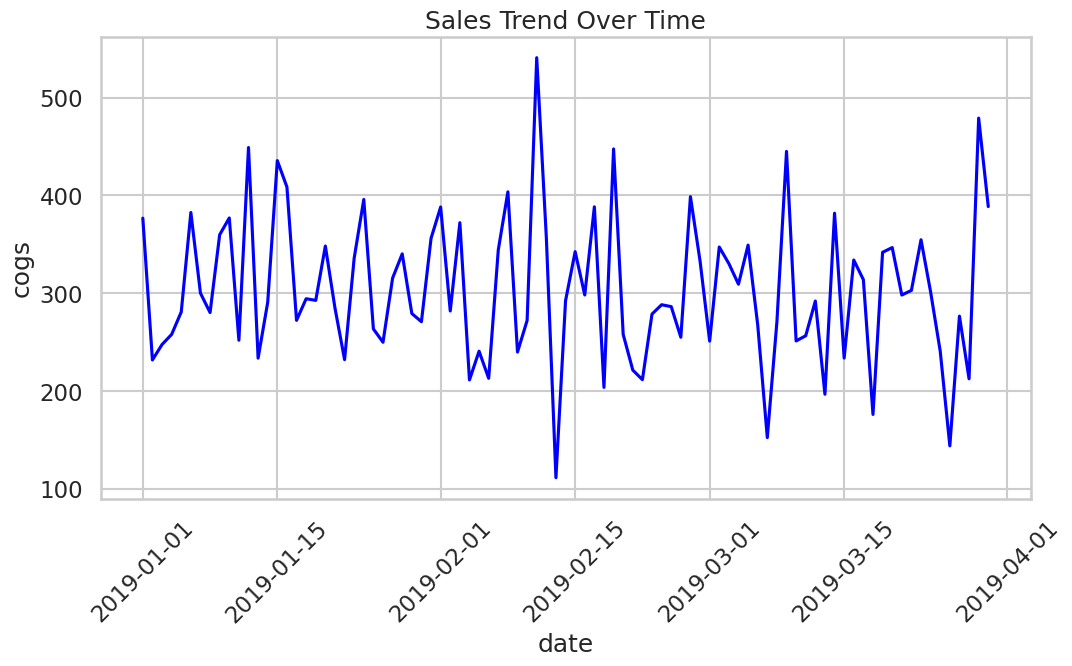

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data.sort_values('date'), x='date', y='cogs', ci=None, color='blue')
plt.xticks(rotation=45)
plt.title("Sales Trend Over Time")
plt.show()

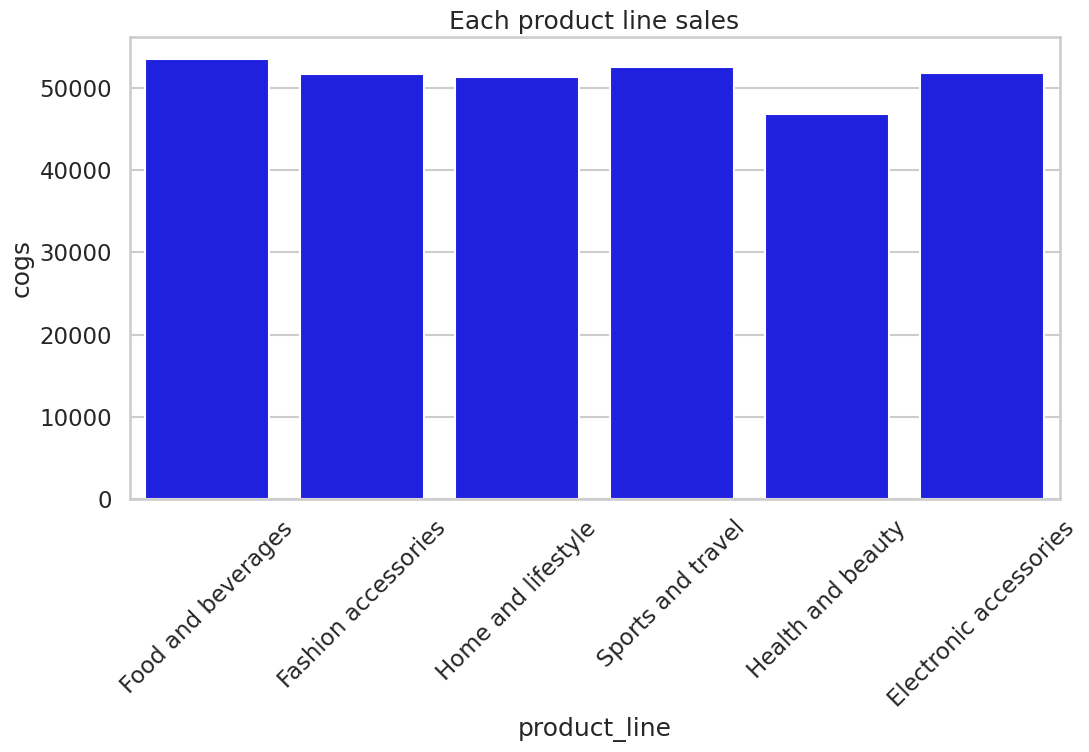

In [111]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data, x='product_line', y='cogs', ci=None, color='blue', estimator=np.sum)
plt.xticks(rotation=45)
plt.title("Each product line sales")
plt.show()

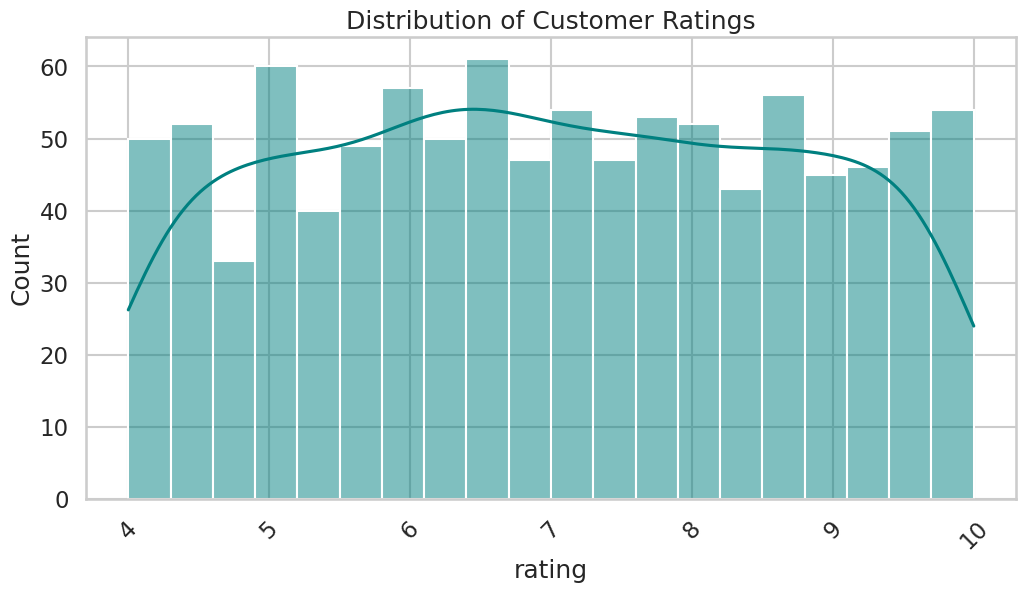

In [117]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data, x = 'rating', bins=20, kde=True, color='teal')
plt.title("Distribution of Customer Ratings")
plt.xticks(rotation=45)
plt.show()

In [135]:
data[(data['customer_type'] == 'Member') & (data['rating'] < 5.0)].groupby(['branch','product_line'])['customer_type'].count()

branch  product_line          
Alex    Electronic accessories    6
        Fashion accessories       5
        Food and beverages        4
        Health and beauty         5
        Home and lifestyle        9
        Sports and travel         3
Cairo   Electronic accessories    3
        Fashion accessories       7
        Food and beverages        4
        Health and beauty         4
        Home and lifestyle        7
        Sports and travel         9
Giza    Electronic accessories    9
        Fashion accessories       4
        Food and beverages        7
        Health and beauty         6
        Home and lifestyle        2
        Sports and travel         2
Name: customer_type, dtype: int64

In [136]:
data['percentage_profit_margin'] = (data['gross_income'] / data['cogs']) * 100

In [137]:
data

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5%,sales,...,time,payment,cogs,gross_margin_percentage,gross_income,rating,month_Name,bulk_order,hour,percentage_profit_margin
856,770-42-8960,Cairo,Mandalay,Normal,Male,Food and beverages,21.12,8,8.448,177.408,...,19:31:00,Cash,168.96,4.761905,8.448,6.3,January,Yes,19,5.0
567,651-88-7328,Alex,Yangon,Normal,Female,Fashion accessories,65.74,9,29.583,621.243,...,13:55:00,Cash,591.66,4.761905,29.583,7.7,January,Yes,13,5.0
245,530-90-9855,Alex,Yangon,Member,Male,Home and lifestyle,47.59,8,19.036,399.756,...,14:47:00,Cash,380.72,4.761905,19.036,5.7,January,Yes,14,5.0
696,182-52-7000,Alex,Yangon,Member,Female,Sports and travel,27.04,4,5.408,113.568,...,20:26:00,Ewallet,108.16,4.761905,5.408,6.9,January,No,20,5.0
523,133-14-7229,Giza,Naypyitaw,Normal,Male,Health and beauty,62.87,2,6.287,132.027,...,11:43:00,Cash,125.74,4.761905,6.287,5.0,January,No,11,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,743-04-1105,Cairo,Mandalay,Member,Male,Health and beauty,97.22,9,43.749,918.729,...,14:43:00,Ewallet,874.98,4.761905,43.749,6.0,March,Yes,14,5.0
881,115-38-7388,Giza,Naypyitaw,Member,Female,Fashion accessories,10.18,8,4.072,85.512,...,12:51:00,Credit card,81.44,4.761905,4.072,9.5,March,Yes,12,5.0
963,364-34-2972,Giza,Naypyitaw,Member,Male,Electronic accessories,96.82,3,14.523,304.983,...,20:37:00,Cash,290.46,4.761905,14.523,6.7,March,No,20,5.0
937,361-85-2571,Alex,Yangon,Normal,Female,Sports and travel,89.48,5,22.370,469.770,...,10:18:00,Cash,447.40,4.761905,22.370,7.4,March,No,10,5.0
